# Учимся работе с данными - от загрузки до моделирования

# 1. Импортируем библиотеки, загружаем датасет и анализируем данные

## 1.1. Первый взгляд на данные

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
df.head(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN


In [5]:
df.drop('id',axis=1,inplace=True)
df.drop('Unnamed: 32',axis=1,inplace=True)

In [6]:
df.isna().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [7]:
df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 1.2. Визуализации

### Общие параметры графики

In [9]:
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    'font.size': 14,             
    'figure.figsize': (10, 6),   
    'axes.labelsize': 14,        
    'xtick.labelsize': 12,      
    'ytick.labelsize': 12,       
    'legend.fontsize': 12        
})

### 1.2.1. Гистограммы распределения признаков

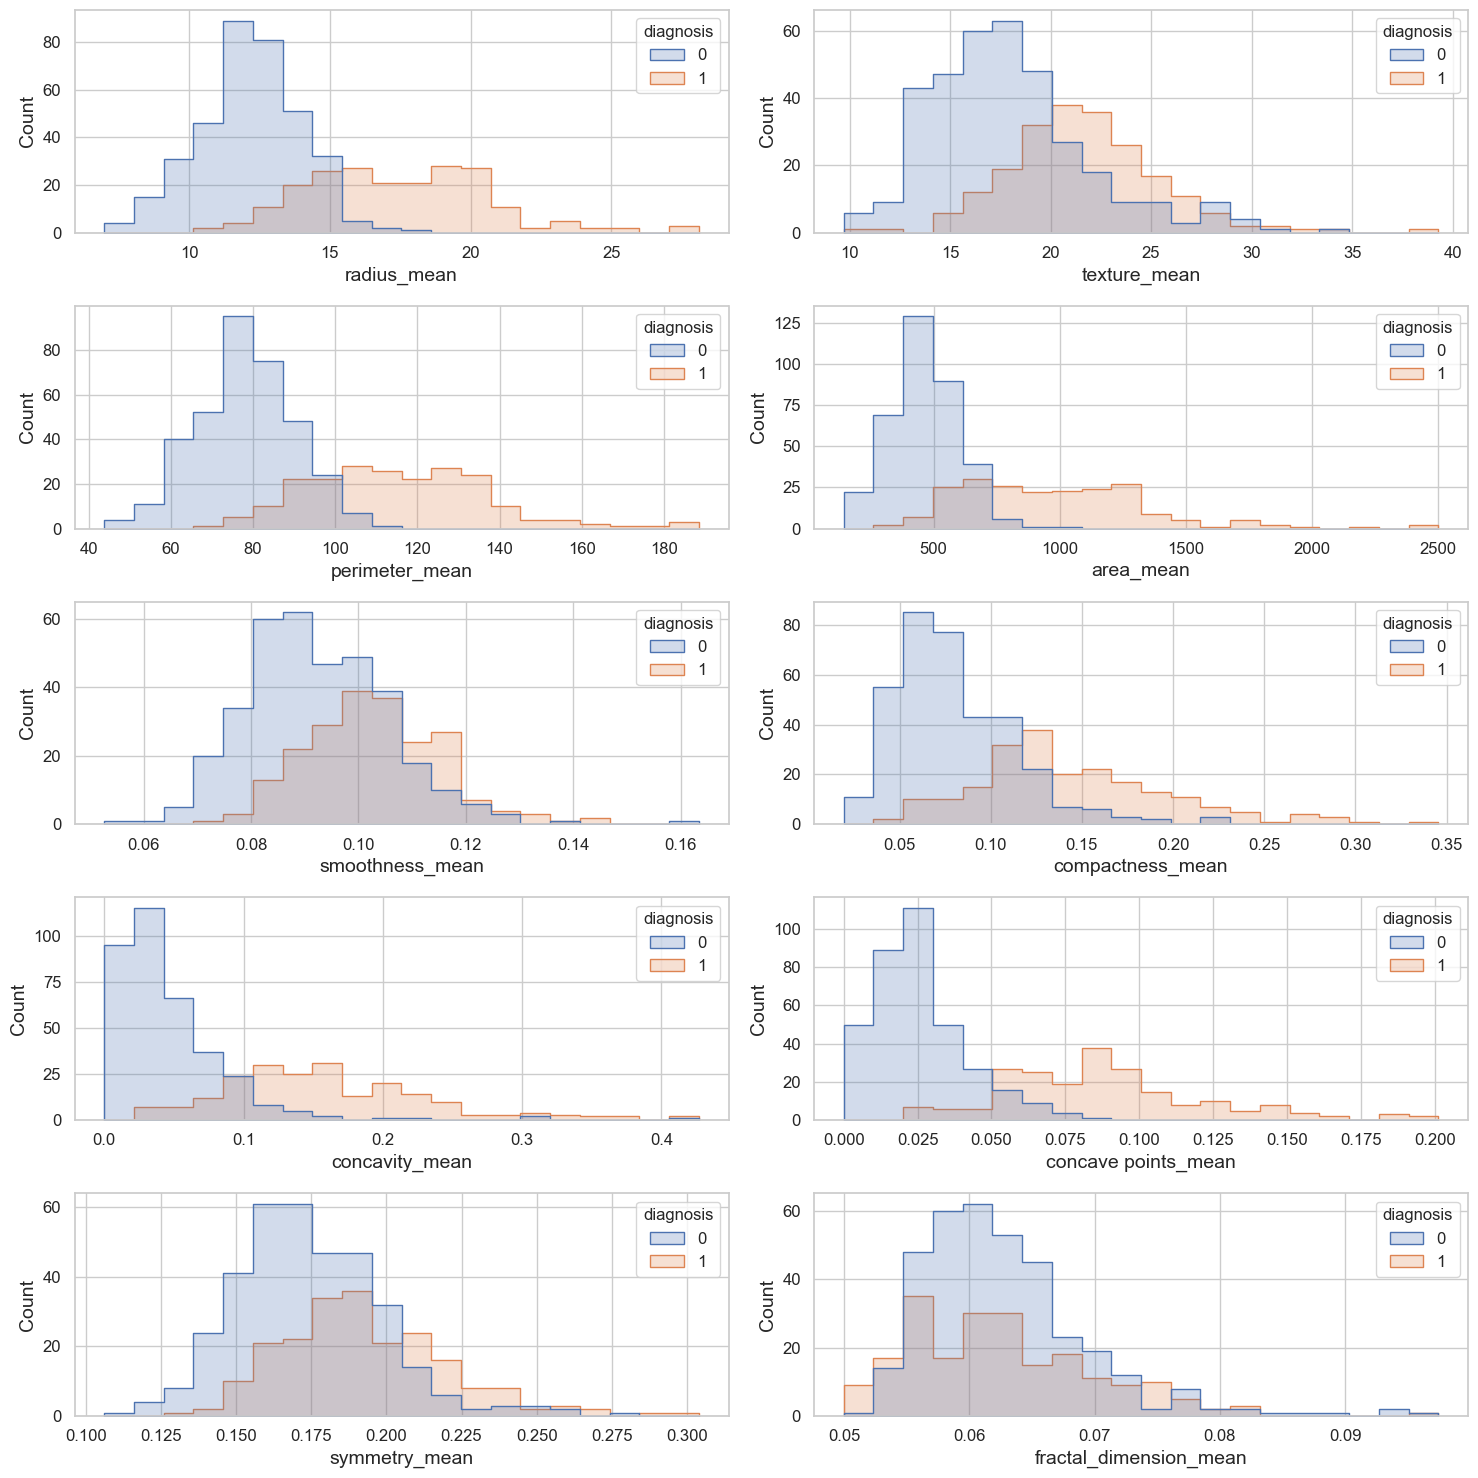

In [10]:
features_mean=list(df.columns[1:11])
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15,15))
axes = axes.ravel()

for idx,ax in enumerate(axes):
    sns.histplot(
        data=df,
        x=df[features_mean[idx]],
        binwidth=(max(df[features_mean[idx]]) - min(df[features_mean[idx]]))/20,
        ax=ax,
        hue='diagnosis',
        element="step",
    )
    
plt.tight_layout()
plt.show()

Видим, что радиус, периметр и площадь образования коррелируют с положительным диагнозом (и друг с другом, очевидно, тоже). Есть также зависимость от неровности контура concavity, concave points)

### 1.2.2.  Матрица корреляций

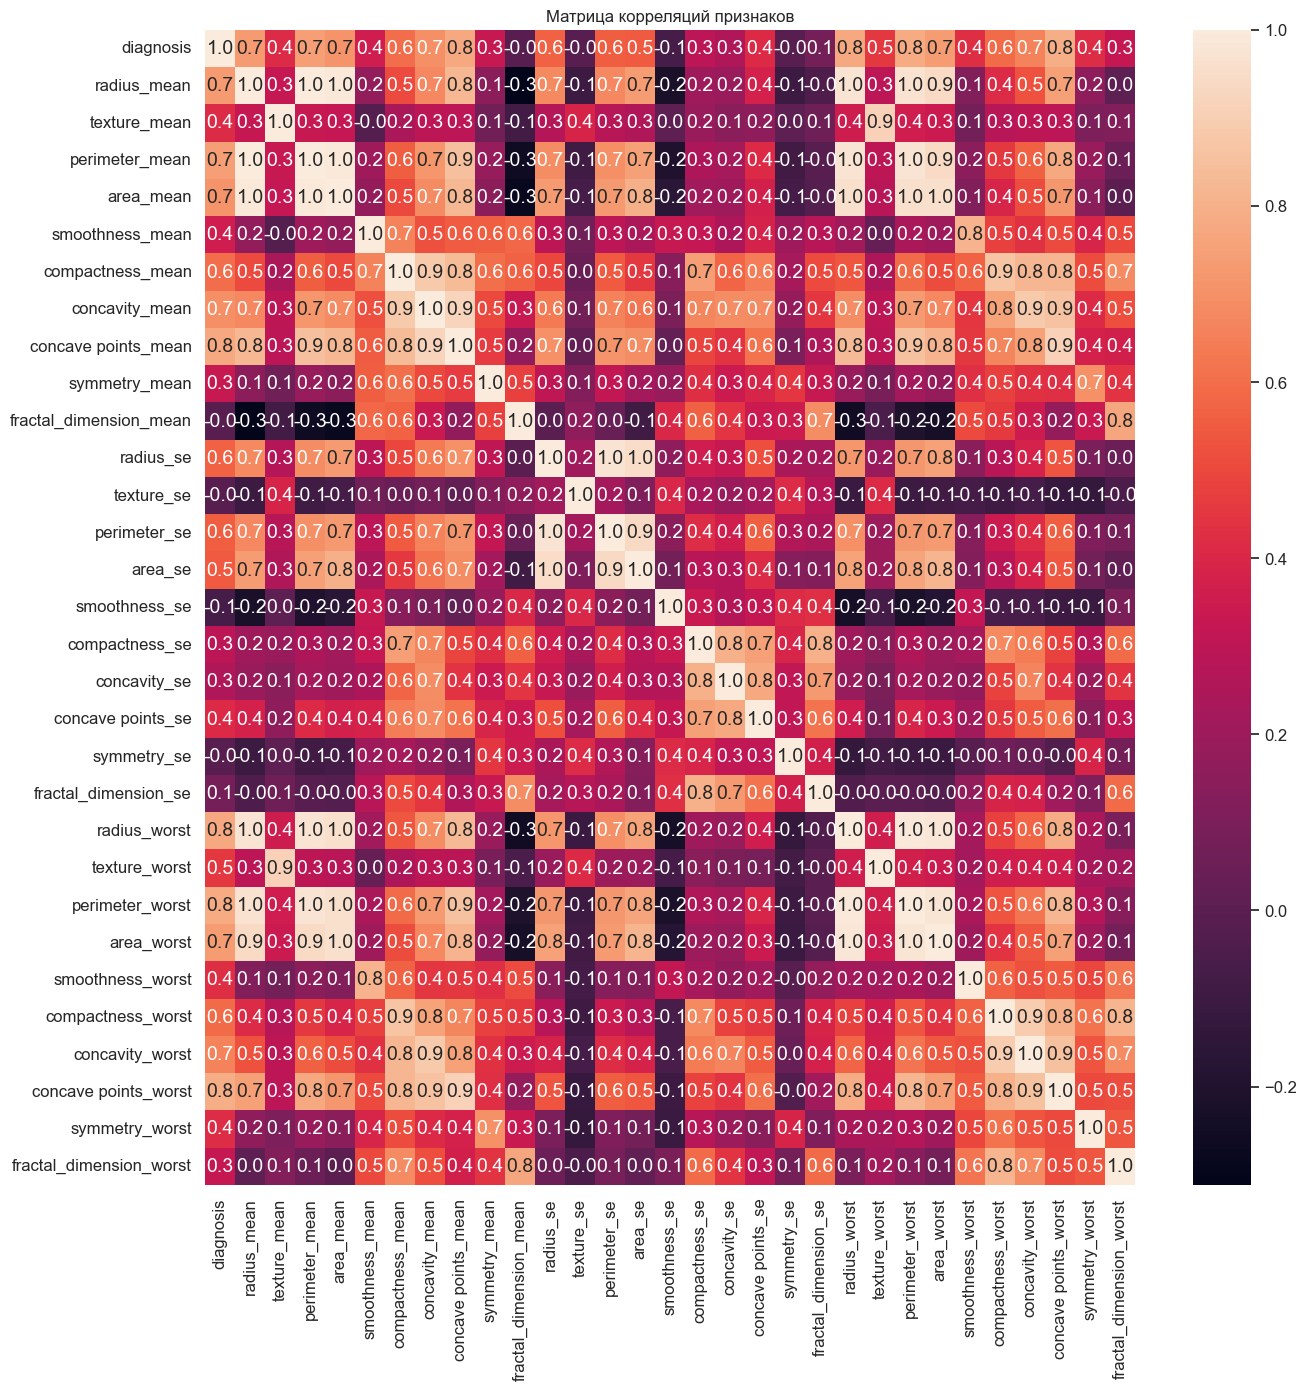

In [11]:
plt.figure(figsize = (15,15))
corr = df.corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.1f'
)

plt.title('Матрица корреляций признаков')
plt.show()

### 1.2.3. Scatterplot

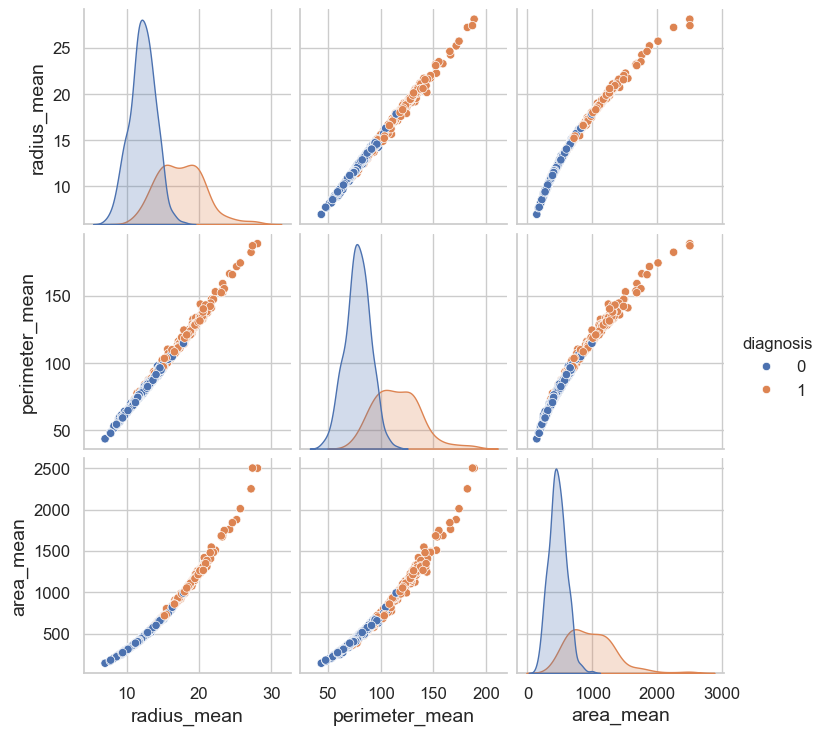

In [12]:
cols=['radius_mean', 'perimeter_mean', 'area_mean', 'diagnosis']
sns.pairplot(
    df[cols],
    hue='diagnosis'
)
plt.show()

Наблюдаем линейную зависимость периметра от радиуса и квадратичную - площади от радиуса.

### 1.2.4. Boxplot

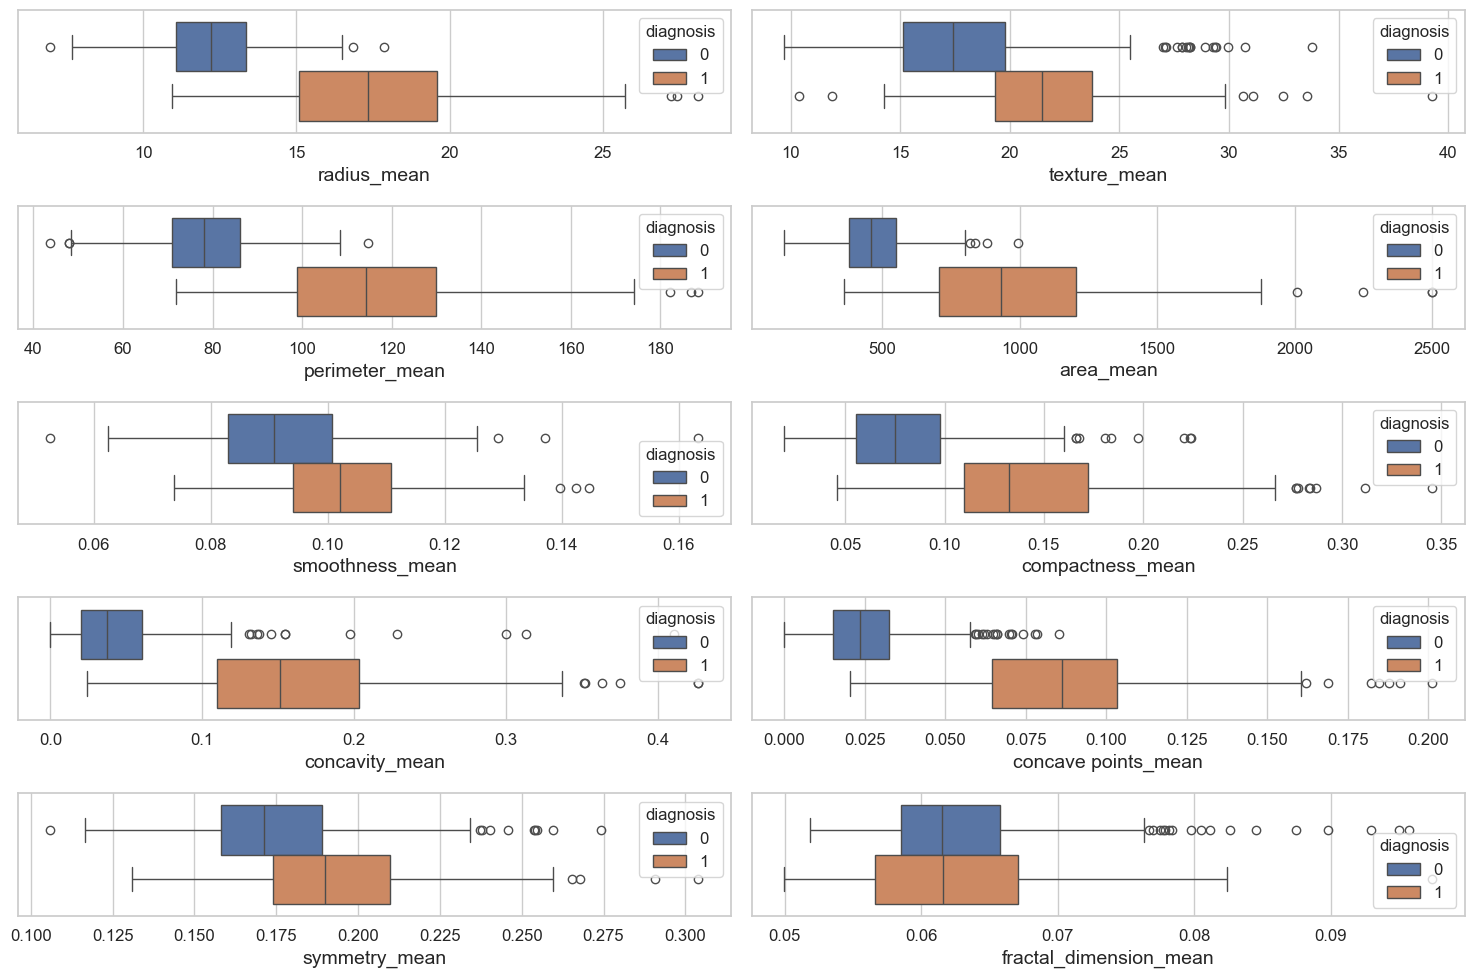

In [13]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15,10))
axes = axes.ravel()

for idx,ax in enumerate(axes):
    sns.boxplot(
        data=df,
        x=df[features_mean[idx]],
        ax=ax,
        hue='diagnosis',
    )
    
plt.tight_layout()
plt.show()

Можно предполагать, что для определения диагноза лучше подходят признаки размера и неровности края образования, так как их распределения целевой переменной наиболее явно смещены друг относительно друга.

## 1.3. Проведем обработку данных

Ранее проведенный анализ показал значимость определенных признаков для прогнозирования. Попробуем создать 2 новых набора данных, основываясь на ручном и автоматизированном отборе признаков.

### 1.3.1. Ручной выбор наиболее информативных признаков

Для начала обратимся к визуализациям и удалим коррелирующие признаки:

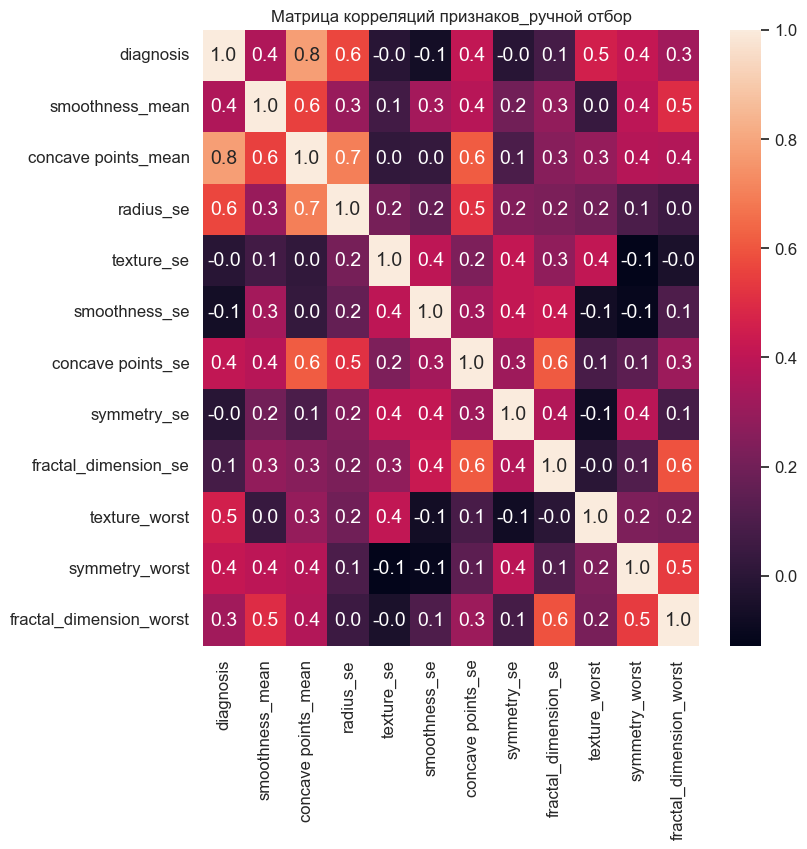

In [14]:
features_to_drop = [
    'perimeter_mean', 'radius_mean', 'area_mean', 'texture_mean',
    'compactness_worst', 'concavity_worst', 'concave points_worst', 'concavity_mean',
    'concavity_se', 'radius_worst', 'perimeter_worst', 'area_se', 'area_worst',
    'perimeter_se', 'smoothness_worst', 'compactness_mean', 'compactness_se',
    'fractal_dimension_mean', 'symmetry_mean'
]
df_manual = df.drop(features_to_drop,axis = 1) 

plt.figure(figsize = (8,8))
corr_manual=df_manual.corr()

sns.heatmap(
    corr_manual,
    annot=True,
    fmt='.1f'
)

plt.title('Матрица корреляций признаков_ручной отбор')
plt.show()



Разделим полученный набор для данных признаков:

In [15]:
from sklearn.model_selection import train_test_split

X_train_manual, X_test_manual, y_train_manual, y_test_manual = train_test_split(
    df_manual.drop('diagnosis', axis=1), 
    df_manual['diagnosis'], 
    test_size=0.3, 
    random_state=42
)

### 1.3.2. Автоматический выбор наиболее информативных признаков

Найдем и посмотрим значимые признаки (будем искать 10 штук):

In [16]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

select_feature = SelectKBest(chi2).fit(df.drop('diagnosis', axis=1), df['diagnosis'])

In [17]:
pd.DataFrame({'features':df.drop('diagnosis', axis=1).columns, 'weights':select_feature.scores_}).sort_values('weights', ascending=False).head(10)

,features,weights
23,area_worst,112598.431564
3,area_mean,53991.655924
13,area_se,8758.504705
22,perimeter_worst,3665.035416
2,perimeter_mean,2011.102864
20,radius_worst,491.689157
0,radius_mean,266.104917
12,perimeter_se,250.571896
21,texture_worst,174.449400
1,texture_mean,93.897508


Получим новый набор данных и проверим корреляции:

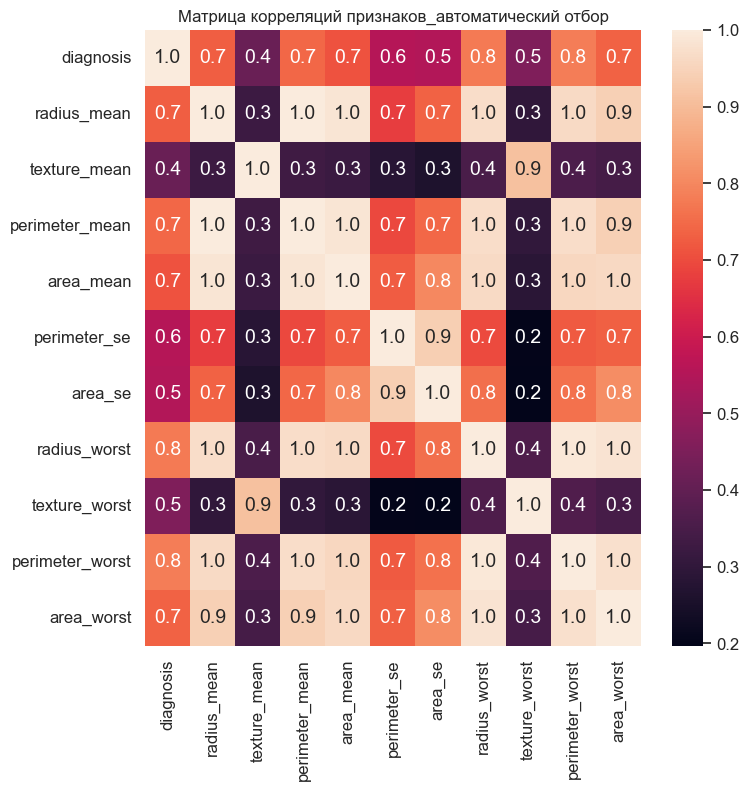

In [18]:
features_to_drop_auto = [
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 
       'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'
]
df_auto = df.drop(features_to_drop_auto,axis = 1) 

plt.figure(figsize = (8,8))
corr_auto=df_auto.corr()

sns.heatmap(
    corr_auto,
    annot=True,
    fmt='.1f'
)

plt.title('Матрица корреляций признаков_автоматический отбор')
plt.show()

Странным образом этот метод предлагает нам оставить как раз наиболее коррелирующие признаки. Посмотрим, что будет дальше.

Изменим данные:

In [19]:
X_train_auto, X_test_auto, y_train_auto, y_test_auto = train_test_split(df.drop('diagnosis', axis=1), df['diagnosis'], test_size=0.3, random_state=42)

In [20]:
SKB=SelectKBest(chi2, k=10)
X_train_auto = SKB.fit_transform(X_train_auto, y_train_auto)

In [21]:
X_test_auto = SKB.transform(X_test_auto)

### 1.3.3. Стандартизация признаков

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler_manual = StandardScaler()
X_train_manual = scaler_manual.fit_transform(X_train_manual)
X_test_manual = scaler_manual.transform(X_test_manual)

In [24]:
scaler_auto = StandardScaler()
X_train_auto = scaler_auto.fit_transform(X_train_auto)
X_test_auto = scaler_auto.transform(X_test_auto)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('diagnosis', axis=1), 
    df['diagnosis'], 
    test_size=0.3, 
    random_state=42
)

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Стандартизация требуется для эффективного обучения, так как признаки имеют различные масштабы, отличающиеся на несколько порядков. На полученных выборках _manual, _auto будем далее обучать модели.

# 2. Моделирование

In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, RocCurveDisplay, confusion_matrix

## 2.1. Базовая модель без подбора гиперпараметров

### 2.1.1. Расчет показателей моделей

Ручная обработка признаков:

In [28]:
knn_manual = KNeighborsClassifier()
knn_manual.fit(X_train_manual, y_train_manual)
y_pred_train_manual = knn_manual.predict(X_train_manual)
y_pred_test_manual = knn_manual.predict(X_test_manual)
    
f1_score_train_manual = f1_score(y_pred_train_manual, y_train_manual)
f1_score_test_manual = f1_score(y_pred_test_manual, y_test_manual)

A_train_manual = accuracy_score(y_pred_train_manual, y_train_manual)
A_test_manual = accuracy_score(y_pred_test_manual, y_test_manual)

P_train_manual = precision_score(y_pred_train_manual, y_train_manual)
P_test_manual = precision_score(y_pred_test_manual, y_test_manual)

R_train_manual = recall_score(y_pred_train_manual, y_train_manual)
R_test_manual = recall_score(y_pred_test_manual, y_test_manual)

Автоматическая обработка признаков:

In [29]:
knn_auto = KNeighborsClassifier()
knn_auto.fit(X_train_auto, y_train_auto)
y_pred_train_auto = knn_auto.predict(X_train_auto)
y_pred_test_auto = knn_auto.predict(X_test_auto)
    
f1_score_train_auto = f1_score(y_pred_train_auto, y_train_auto)
f1_score_test_auto = f1_score(y_pred_test_auto, y_test_auto)

A_train_auto = accuracy_score(y_pred_train_auto, y_train_auto)
A_test_auto = accuracy_score(y_pred_test_auto, y_test_auto)

P_train_auto = precision_score(y_pred_train_auto, y_train_auto)
P_test_auto = precision_score(y_pred_test_auto, y_test_auto)

R_train_auto = recall_score(y_pred_train_auto, y_train_auto)
R_test_auto = recall_score(y_pred_test_auto, y_test_auto)

Исходный набор:

In [30]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_train = knn.predict(X_train)
y_pred_test = knn.predict(X_test)
    
f1_score_train = f1_score(y_pred_train, y_train)
f1_score_test = f1_score(y_pred_test, y_test)

A_train = accuracy_score(y_pred_train, y_train)
A_test = accuracy_score(y_pred_test, y_test)

P_train = precision_score(y_pred_train, y_train)
P_test = precision_score(y_pred_test, y_test)

R_train = recall_score(y_pred_train, y_train)
R_test = recall_score(y_pred_test, y_test)

### 2.1.2. Расчет показателей ROC-AUC

In [31]:
y_score_manual = knn_manual.predict_proba(X_test_manual)
y_score_auto = knn_auto.predict_proba(X_test_auto)
y_score = knn.predict_proba(X_test)

In [32]:
RAS_manual=roc_auc_score(y_test_manual, y_score_manual[:,1])
print(f'roc_auc_score = {RAS_manual:.3f}')

roc_auc_score = 0.965


In [33]:
RAS_auto=roc_auc_score(y_test_auto, y_score_auto[:,1])
print(f'roc_auc_score = {RAS_auto:.3f}')

roc_auc_score = 0.986


In [34]:
RAS_base=roc_auc_score(y_test, y_score[:,1])
print(f'roc_auc_score = {RAS_base:.3f}')

roc_auc_score = 0.979


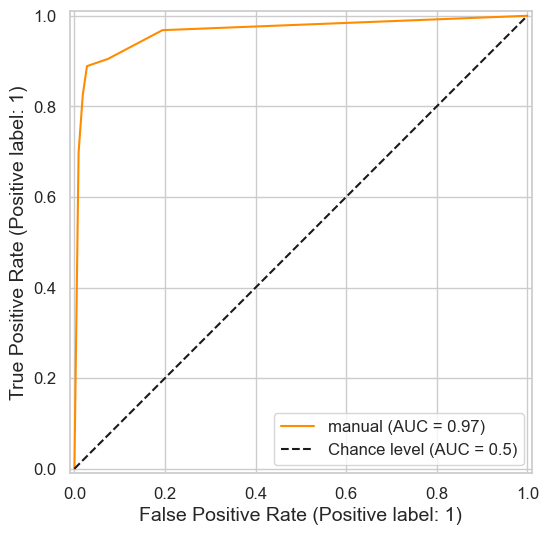

In [35]:
display = RocCurveDisplay.from_predictions(
    y_test_manual,
    y_score_manual[:,1],
    color="darkorange",
    plot_chance_level=True,
    name='manual',
)

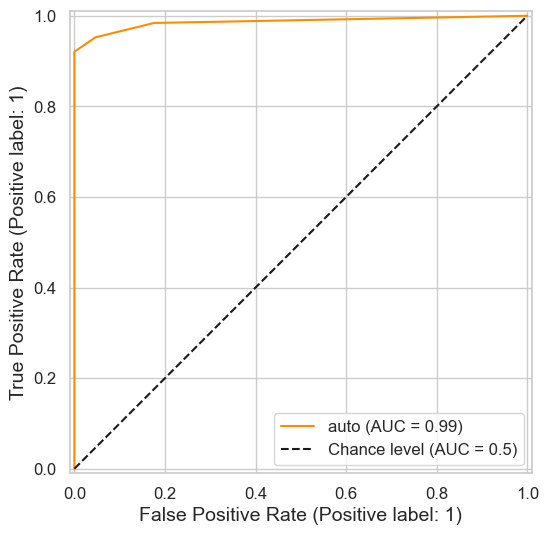

In [36]:
display = RocCurveDisplay.from_predictions(
    y_test_auto,
    y_score_auto[:,1],
    color="darkorange",
    plot_chance_level=True,
    name='auto'
)

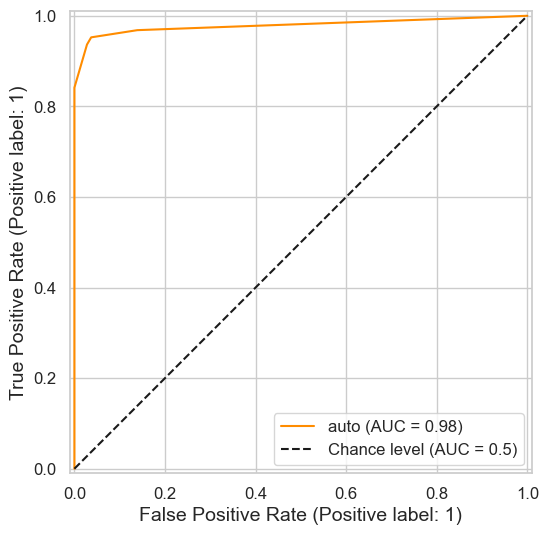

In [37]:
display = RocCurveDisplay.from_predictions(
    y_test,
    y_score[:,1],
    color="darkorange",
    plot_chance_level=True,
    name='auto'
)

### 2.1.3. Сводная таблица оценок

In [38]:
score_data=pd.DataFrame(
    {'manual_base':
     [f1_score_train_manual,
      f1_score_test_manual, 
      A_train_manual, 
      A_test_manual, 
      P_train_manual, 
      P_test_manual, 
      R_train_manual,
      R_test_manual,
     ],
     'auto_base':
     [f1_score_train_auto,
      f1_score_test_auto, 
      A_train_auto, 
      A_test_auto, 
      P_train_auto, 
      P_test_auto, 
      R_train_auto,
      R_test_auto,
     ],
     'base':
     [f1_score_train,
      f1_score_test, 
      A_train, 
      A_test, 
      P_train, 
      P_test, 
      R_train,
      R_test,
     ]
    }
)

In [39]:
score_data['train_test']=['train', 'test']*4
score_data['score']=['f1_score']*2 + ['accuracy']*2 + ['precision']*2 + ['recall']*2
score_data=score_data.set_index(['score','train_test'])
score_data

manual_base  auto_base      base
score     train_test                                  
f1_score  train          0.944444   0.916084  0.968858
          test           0.918033   0.958678  0.944000
accuracy  train          0.959799   0.939698  0.977387
          test           0.941520   0.970760  0.959064
precision train          0.912752   0.879195  0.939597
          test           0.888889   0.920635  0.936508
recall    train          0.978417   0.956204  1.000000
          test           0.949153   1.000000  0.951613

### 2.1.4. Визуализация

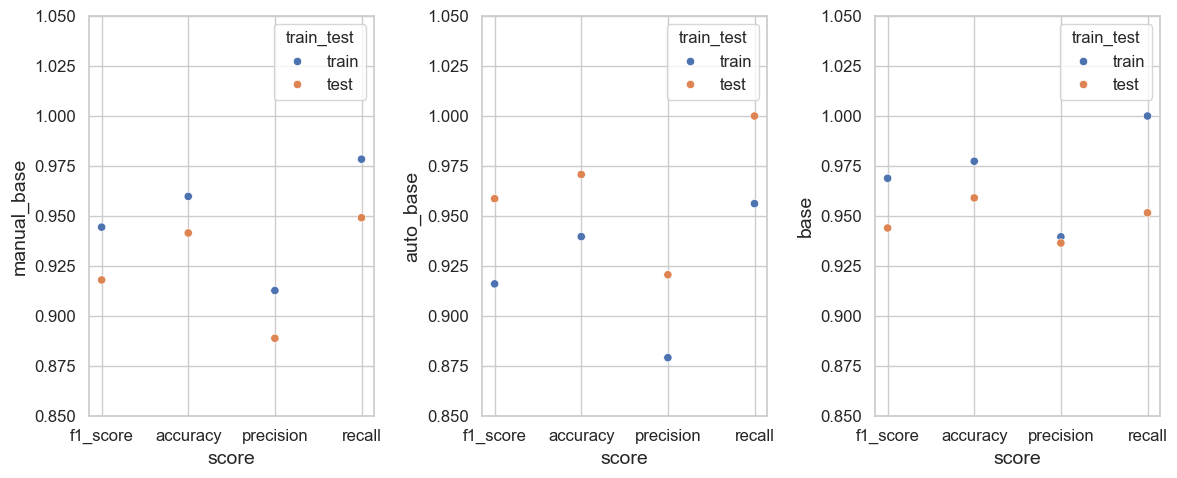

In [40]:
features=list(score_data.columns[0:3])
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,5))
axes = axes.ravel()

for idx,ax in enumerate(axes):
    sns.scatterplot(
        data=score_data,
        x='score',
        y=score_data[features[idx]],
        hue='train_test',
        ax=ax
    ).set_ylim(ymin=0.85, ymax=1.05)
        
plt.tight_layout()
plt.show()


### Выводы

Можно наблюдать, как базовая модель показывает хорошие результаты даже на исходном наборе.
Автоматический выбор признаков поднимает результаты на тесте выше, чем на обучении и доводит полноту до 1, то есть верно прогнозирует все опасные новообразования и имеет при этом высокую точность (не ставит слишком много ложноположительных диагнозов). Для медицинских моделей вообще-то это идеал.

Однако такие результаты (высокими значениями вплоть до единицы на тесте) заставляют сомневаться в правоте модели после автоматического выбора признаков.

Также возникает ощущение, что фильтрация признаков вообще не требуется для модели kNN, которая неплохо работает и на полном наборе.

## 2.2. Модель с подбором гиперпараметров

### 2.2.1. Расчет показателей модели

Обучение проведем на полном наборе данных, разделенном ранее на выборки

In [41]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [42]:
pipe = Pipeline([
    ("knn", KNeighborsClassifier())
])

param_grid = {
    "knn__n_neighbors": list(range(1, 21)),
    "knn__weights": ["uniform", "distance"]
}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid=param_grid, cv=cv, scoring='roc_auc')

In [43]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'knn__n_neighbors': [1, 2, ...], 'knn__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

In [44]:
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая оценка: {grid.best_score_:.4f}")

Лучшие параметры: {'knn__n_neighbors': 18, 'knn__weights': 'uniform'}
Лучшая оценка: 0.9906


In [45]:
knn_best = grid.best_estimator_

In [46]:
y_pred_res = knn_best.predict(X_test)
y_proba_res = knn_best.predict_proba(X_test)[:,1]

f1_score_res = f1_score(y_pred_res, y_test)
A_res = accuracy_score(y_pred_res, y_test)
P_res = precision_score(y_pred_res, y_test)
R_res = recall_score(y_pred_res, y_test)
RAS_res = roc_auc_score(y_test, y_proba_res)

print(f'roc_auc_score = {RAS_res:.3f}')

roc_auc_score = 0.993


### 2.2.2. Сводная таблица оценок итоговая

In [47]:
score_data['baseline']=['-', f1_score_res, '-', A_res, '-', P_res, '-', R_res]
score_data.loc[('roc-auc-score','test'),:]=RAS_manual, RAS_auto, RAS_base, RAS_res
score_data

manual_base  auto_base      base  baseline
score         train_test                                            
f1_score      train          0.944444   0.916084  0.968858         -
              test           0.918033   0.958678  0.944000   0.92562
accuracy      train          0.959799   0.939698  0.977387         -
              test           0.941520   0.970760  0.959064  0.947368
precision     train          0.912752   0.879195  0.939597         -
              test           0.888889   0.920635  0.936508  0.888889
recall        train          0.978417   0.956204  1.000000         -
              test           0.949153   1.000000  0.951613  0.965517
roc-auc-score test           0.965241   0.986405  0.978689  0.993019

### Выводы

Видим некоторый прирост качества. Это хорошо. Значит, подобрать оптимальные параметры можно.

# 3. Моделирование логистической регрессии

In [48]:
from sklearn.linear_model import LogisticRegression

## 3.1. Базовая модель

### 3.1.1. Расчет показателей моделей

Ручная обработка признаков:

In [49]:
lr_manual = LogisticRegression()

lr_manual.fit(X_train_manual, y_train_manual)
y_lr_pred_train_manual = lr_manual.predict(X_train_manual)
y_lr_pred_test_manual = lr_manual.predict(X_test_manual)

f1_score_lr_train_manual = f1_score(y_lr_pred_train_manual, y_train_manual)
f1_score_lr_test_manual = f1_score(y_lr_pred_test_manual, y_test_manual)

A_lr_train_manual = accuracy_score(y_lr_pred_train_manual, y_train_manual)
A_lr_test_manual = accuracy_score(y_lr_pred_test_manual, y_test_manual)

P_lr_train_manual = precision_score(y_lr_pred_train_manual, y_train_manual)
P_lr_test_manual = precision_score(y_lr_pred_test_manual, y_test_manual)

R_lr_train_manual = recall_score(y_lr_pred_train_manual, y_train_manual)
R_lr_test_manual = recall_score(y_lr_pred_test_manual, y_test_manual)

Автоматическая обработка признаков:

In [50]:
lr_auto = LogisticRegression()

lr_auto.fit(X_train_auto, y_train_auto)
y_lr_pred_train_auto = lr_auto.predict(X_train_auto)
y_lr_pred_test_auto = lr_auto.predict(X_test_auto)

f1_score_lr_train_auto = f1_score(y_lr_pred_train_auto, y_train_auto)
f1_score_lr_test_auto = f1_score(y_lr_pred_test_auto, y_test_auto)

A_lr_train_auto = accuracy_score(y_lr_pred_train_auto, y_train_auto)
A_lr_test_auto = accuracy_score(y_lr_pred_test_auto, y_test_auto)

P_lr_train_auto = precision_score(y_lr_pred_train_auto, y_train_auto)
P_lr_test_auto = precision_score(y_lr_pred_test_auto, y_test_auto)

R_lr_train_auto = recall_score(y_lr_pred_train_auto, y_train_auto)
R_lr_test_auto = recall_score(y_lr_pred_test_auto, y_test_auto)

Исходный набор:

In [51]:
lr = LogisticRegression()

lr.fit(X_train, y_train)
y_lr_pred_train = lr.predict(X_train)
y_lr_pred_test = lr.predict(X_test)

f1_score_lr_train = f1_score(y_lr_pred_train, y_train)
f1_score_lr_test = f1_score(y_lr_pred_test, y_test)

A_lr_train = accuracy_score(y_lr_pred_train, y_train)
A_lr_test = accuracy_score(y_lr_pred_test, y_test)

P_lr_train = precision_score(y_lr_pred_train, y_train)
P_lr_test = precision_score(y_lr_pred_test, y_test)

R_lr_train = recall_score(y_lr_pred_train, y_train)
R_lr_test = recall_score(y_lr_pred_test, y_test)

### 3.1.2. Расчет показателей ROC-AUC

In [52]:
y_lr_score_manual = lr_manual.predict_proba(X_test_manual)
y_lr_score_auto = lr_auto.predict_proba(X_test_auto)
y_lr_score = lr.predict_proba(X_test)

In [53]:
RAS_lr_manual=roc_auc_score(y_test_manual, y_lr_score_manual[:,1])
print(f'roc_auc_score = {RAS_lr_manual:.3f}')

roc_auc_score = 0.994


In [54]:
RAS_lr_auto=roc_auc_score(y_test_auto, y_lr_score_auto[:,1])
print(f'roc_auc_score = {RAS_lr_auto:.3f}')

roc_auc_score = 0.995


In [55]:
RAS_lr_base=roc_auc_score(y_test, y_lr_score[:,1])
print(f'roc_auc_score = {RAS_lr_base:.3f}')

roc_auc_score = 0.998


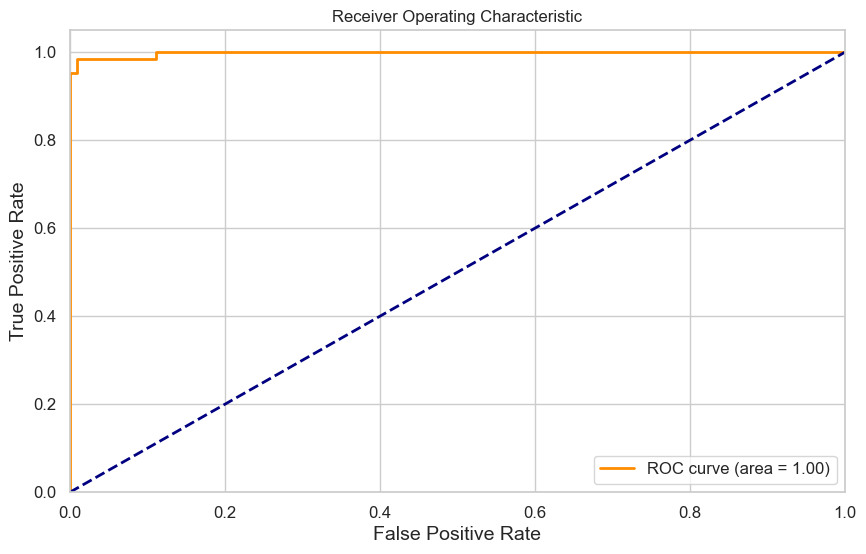

In [56]:
fpr, tpr, thresholds = roc_curve(y_test, y_lr_score[:,1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### 3.1.3. Сводная таблица оценок

In [57]:
score_data_lr=pd.DataFrame(
    {'manual_base':
     [f1_score_lr_train_manual,
      f1_score_lr_test_manual, 
      A_lr_train_manual, 
      A_lr_test_manual, 
      P_lr_train_manual, 
      P_lr_test_manual, 
      R_lr_train_manual,
      R_lr_test_manual,
     ],
     'auto_base':
     [f1_score_lr_train_auto,
      f1_score_lr_test_auto, 
      A_lr_train_auto, 
      A_lr_test_auto, 
      P_lr_train_auto, 
      P_lr_test_auto, 
      R_lr_train_auto,
      R_lr_test_auto,
     ],
     'base':
     [f1_score_lr_train,
      f1_score_lr_test, 
      A_lr_train, 
      A_lr_test, 
      P_lr_train, 
      P_lr_test, 
      R_lr_train,
      R_lr_test,
     ]
    }
)

In [58]:
score_data_lr['train_test']=['train', 'test']*4
score_data_lr['score']=['f1_score']*2 + ['accuracy']*2 + ['precision']*2 + ['recall']*2
score_data_lr=score_data_lr.set_index(['score','train_test'])
score_data_lr

manual_base  auto_base      base
score     train_test                                  
f1_score  train          0.969283   0.920415  0.983051
          test           0.928000   0.960000  0.976378
accuracy  train          0.977387   0.942211  0.987437
          test           0.947368   0.970760  0.982456
precision train          0.953020   0.892617  0.973154
          test           0.920635   0.952381  0.984127
recall    train          0.986111   0.950000  0.993151
          test           0.935484   0.967742  0.968750

### 3.1.4. Визуализация

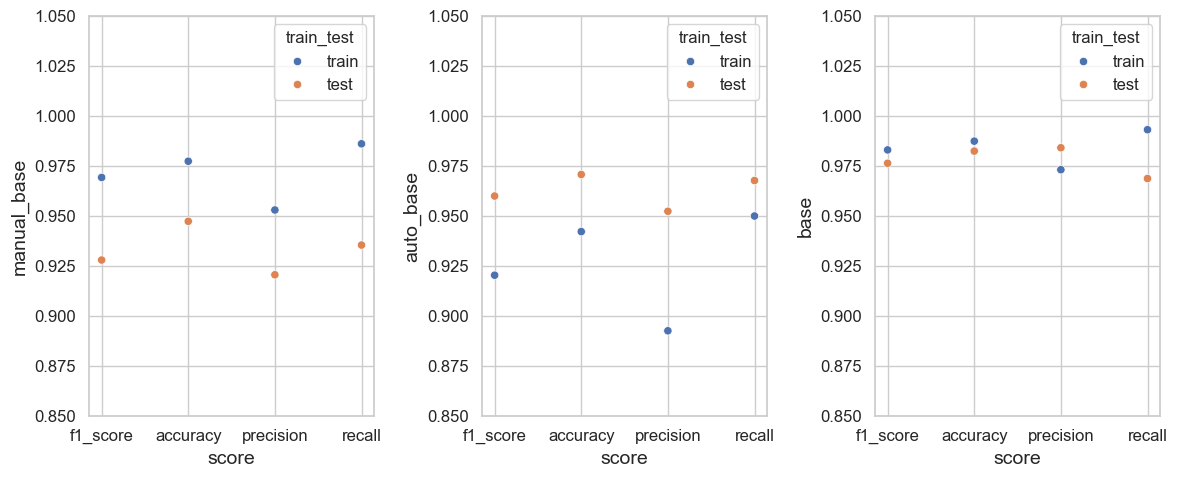

In [59]:
features=list(score_data_lr.columns[0:3])
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,5))
axes = axes.ravel()

for idx,ax in enumerate(axes):
    sns.scatterplot(
        data=score_data_lr,
        x='score',
        y=score_data_lr[features[idx]],
        hue='train_test',
        ax=ax
    ).set_ylim(ymin=0.85, ymax=1.05)
        
plt.tight_layout()
plt.show()


### 3.1.5. Влияние признаков

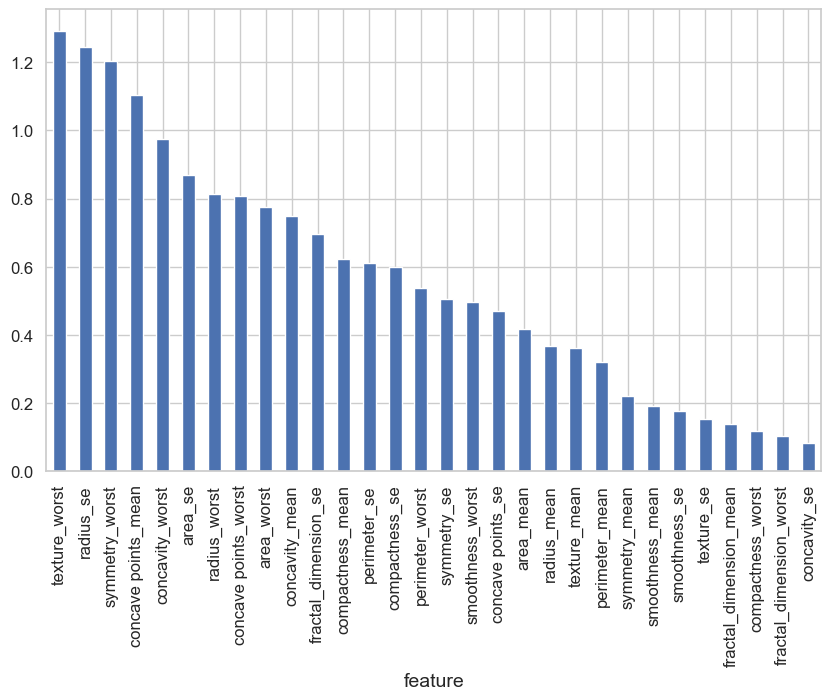

In [60]:
featureImportance = pd.DataFrame({"feature": df.drop('diagnosis',axis=1).columns,
                                  "importance": abs(lr.coef_[0])})

featureImportance.set_index('feature', inplace=True)
featureImportance.sort_values(["importance"], ascending=False, inplace=True)
featureImportance["importance"].plot.bar();

### Выводы

Общая тенденция аналогично модели kNN: на полном наборе модель обучается лучше всех, а набор с автоматическим выбором признаков показывает на тесте лучшие результаты, чем на обучении.

При этом логистическая регрессия имеет в целом лучшие результаты, чем kNN.

Но вызывает некоторое недоумение тот факт, что ручной отбор коррелирующих признаков снижает качество модели.

## 3.2. Модель с кросс-валидацией

### 3.2.1. Расчет показателей модели


In [61]:
from sklearn.linear_model import LogisticRegressionCV

In [62]:
lrCV = LogisticRegressionCV()

parameters = {'Cs': [0.001, 0.01, 0.1, 1, 10]}

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
grid = GridSearchCV(lrCV, parameters, scoring = 'roc_auc', cv = cv)

In [63]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegressionCV()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'Cs': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [64]:
lrCV_best = grid.best_estimator_

In [65]:
print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая оценка: {grid.best_score_:.4f}")

Лучшие параметры: {'Cs': 10}
Лучшая оценка: 0.9929


In [66]:
y_lrCV_pred_res = lrCV_best.predict(X_test)
y_lrCV_proba_res = lrCV_best.predict_proba(X_test)[:,1]

f1_score_lrCV_res = f1_score(y_lrCV_pred_res, y_test)
A_lrCV_res = accuracy_score(y_lrCV_pred_res, y_test)
P_lrCV_res = precision_score(y_lrCV_pred_res, y_test)
R_lrCV_res = recall_score(y_lrCV_pred_res, y_test)
RAS_lrCV_res = roc_auc_score(y_test, y_lrCV_proba_res)

print(f'roc_auc_score = {RAS_lrCV_res:.3f}')

roc_auc_score = 0.997


### 3.2.2. Сводная таблица оценок итоговая


In [67]:
score_data_lr['baseline']=['-', f1_score_lrCV_res, '-', A_lrCV_res, '-', P_lrCV_res, '-', R_lrCV_res]
score_data_lr.loc[('roc-auc-score','test'),:]=RAS_lr_manual, RAS_lr_auto, RAS_lr_base, RAS_lrCV_res
score_data_lr

manual_base  auto_base      base  baseline
score         train_test                                            
f1_score      train          0.969283   0.920415  0.983051         -
              test           0.928000   0.960000  0.976378  0.976378
accuracy      train          0.977387   0.942211  0.987437         -
              test           0.947368   0.970760  0.982456  0.982456
precision     train          0.953020   0.892617  0.973154         -
              test           0.920635   0.952381  0.984127  0.984127
recall        train          0.986111   0.950000  0.993151         -
              test           0.935484   0.967742  0.968750   0.96875
roc-auc-score test           0.993680   0.995444  0.997942  0.996767

### 3.2.3. Влияние признаков

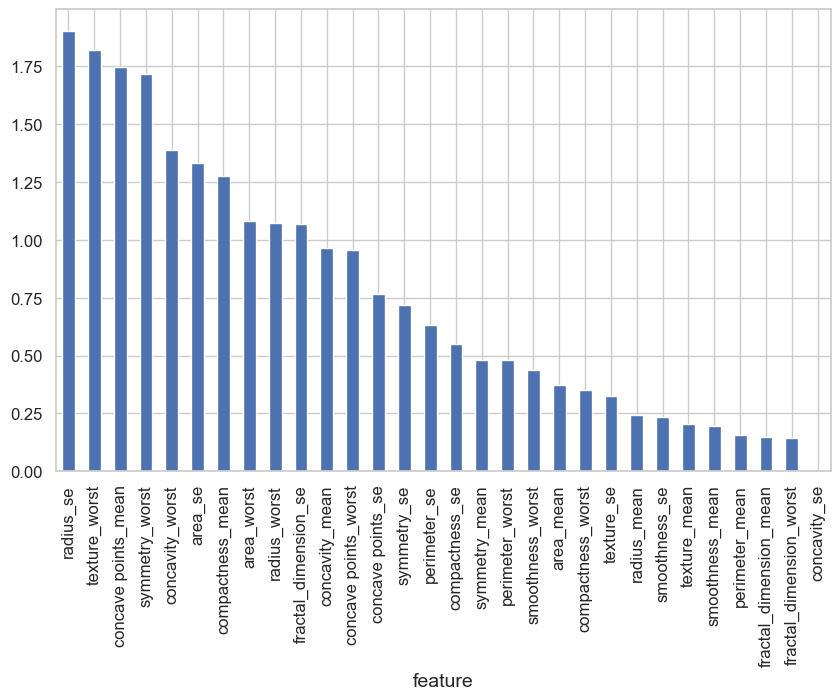

In [68]:
featureImportance_CV = pd.DataFrame({"feature": df.drop('diagnosis',axis=1).columns,
                                  "importance": abs(lrCV_best.coef_[0])})

featureImportance_CV.set_index('feature', inplace=True)
featureImportance_CV.sort_values(["importance"], ascending=False, inplace=True)
featureImportance_CV["importance"].plot.bar();

### Выводы

Видим, что перебор параметров при кросс-валидации не дает улучшений, а даже наоборот - снижает показатель roc-auc. При этом все остальные показатели подозрительно похожи на базовую модель.

В целом выходит, что в данном случае самое верное решение - обучить стандартную логистическую регрессию с параметрами по умолчанию на полном нормализованном наборе данных без отбора признаков.